# Module 2: Appreciating, Interpreting and Visualizing Data

**Project: Understanding Customer Segments for Targeted Marketing**

Introduction: The Power of Customer Segmentation
---



Welcome to your Module 2 project!

In today's competitive landscape, understanding your customers is paramount for any business. Generic marketing strategies often fall flat, but by truly appreciating the diverse needs and behaviors within your customer base, businesses can create more effective, personalized experiences. This process is known as **customer segmentation**,

Customer segmentation involves dividing a broad customer base into subgroups of consumers who have common needs, interests, and priorities. By segmenting customers, companies can:

* **Tailor Marketing Messages:** Design specific campaigns that resonate with each group.
* **Optimize Product Development:** Create products and services that meet the unique demands of different segments.
* **Improve Customer Service:** Provide support that addresses common issues for particular groups.
* **Identify High-Value Customers:** Focus resources on segments that drive the most revenue.
* **Predict Churn:** Identify customers at risk of leaving and intervene proactively.

In this project, your task is to analyze a dataset of customer activity, use dimensionality reduction techniques to visualize customer behavior, and ultimately identify distinct customer segments. This will demonstrate how data visualization can provide actionable insights for business strategy, even without deep domain expertise at the outset.

We will first focus on a synthetic dataset containing various metrics related to customer purchasing habits and engagement. Your goal will be to:
* Process and prepare the raw customer data.
* Use **Principal Component Analysis (PCA)** to understand the main drivers of customer variation.
* Employ **t-Distributed Stochastic Neighbor Embedding (t-SNE)** to uncover hidden clusters of similar customers.
* (Optional Challenge) Explore **Uniform Manifold Approximation and Projection (UMAP)** for an alternative perspective.
* Interpret these visualizations to describe potential customer segments and suggest business implications.

Let's begin by setting up our environment and loading our customer data!


# 1. Data Acquisition and Initial Exploration

For this tutorial, we will first work with a synthetic dataset named ecommerce_customer_data.csv. This file contains anonymized data representing various aspects of customer engagement and purchasing behavior over a period.

First, let's ensure we have our necessary libraries installed and then load the dataset.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# from umap import UMAP # Uncomment if you plan to use UMAP

# For better progress bars with some operations
from tqdm.autonotebook import tqdm

In [27]:
# Load the dataset
try:
    data = pd.read_csv("ecommerce_customer_data.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("ecommerce_customer_data.csv not found. Creating a synthetic dataset...")
    # Create a synthetic dataset if the file doesn't exist
    np.random.seed(42)
    num_customers = 500

    data = pd.DataFrame({
        'CustomerID': np.arange(1, num_customers + 1),
        'Age': np.random.randint(18, 70, num_customers),
        'Gender': np.random.choice(['Male', 'Female'], num_customers),
        'Average_Order_Value': np.random.normal(50, 20, num_customers).round(2).clip(min=5),
        'Number_of_Purchases': np.random.randint(1, 30, num_customers),
        'Days_Since_Last_Purchase': np.random.randint(1, 180, num_customers),
        'Product_Category_Preference': np.random.choice(['Electronics', 'Apparel', 'Books', 'Home Goods', 'Beauty'], num_customers),
        'Customer_Lifetime_Value': np.random.normal(200, 100, num_customers).round(2).clip(min=10)
    })
    # Introduce some correlations to create 'segments'
    data.loc[data['Age'] < 25, 'Product_Category_Preference'] = np.random.choice(['Electronics', 'Apparel'], sum(data['Age'] < 25))
    data.loc[data['Age'] < 25, 'Average_Order_Value'] = np.random.normal(30, 10, sum(data['Age'] < 25)).round(2).clip(min=5)
    data.loc[data['Product_Category_Preference'] == 'Books', 'Number_of_Purchases'] = np.random.randint(10, 40, sum(data['Product_Category_Preference'] == 'Books'))
    data.loc[data['Product_Category_Preference'] == 'Books', 'Customer_Lifetime_Value'] = np.random.normal(300, 150, sum(data['Product_Category_Preference'] == 'Books')).round(2).clip(min=10)
    data.loc[data['Number_of_Purchases'] > 20, 'Average_Order_Value'] = np.random.normal(70, 25, sum(data['Number_of_Purchases'] > 20)).round(2).clip(min=5)

    data.to_csv("ecommerce_customer_data.csv", index=False)
    print("Synthetic dataset created and saved as ecommerce_customer_data.csv")


Dataset loaded successfully!


In [28]:
print("\nDataset Head:")
print(data.head())
print("\nDataset Info:")
data.info()
print("\nDataset Description:")
print(data.describe())


Dataset Head:
   CustomerID  Age  Gender  Average_Order_Value  Number_of_Purchases  \
0           1   56  Female                15.93                    2   
1           2   69    Male                48.89                   15   
2           3   46    Male                57.68                   14   
3           4   32  Female                49.35                   20   
4           5   60    Male                64.78                   22   

   Days_Since_Last_Purchase Product_Category_Preference  \
0                        49                  Home Goods   
1                        35                     Apparel   
2                       172                 Electronics   
3                       102                     Apparel   
4                        11                  Home Goods   

   Customer_Lifetime_Value  
0                   193.68  
1                    47.85  
2                   218.16  
3                   370.92  
4                    87.96  

Dataset Info:
<class '

From the initial look, we have numerical features like Age, Average_Order_Value, Number_of_Purchases, Days_Since_Last_Purchase, and Customer_Lifetime_Value. We also have categorical features: Gender and Product_Category_Preference. CustomerID is just an identifier.

# 2. Feature Engineering and Preprocessing

Before we can apply dimensionality reduction techniques, we need to convert all our features into a numerical format and scale them appropriately. This is crucial because algorithms like PCA and t-SNE are sensitive to the magnitude of the features.

Here's our plan:
* **Drop CustomerID:** It's an identifier and doesn't contain behavioral information.
* **One-Hot Encode Categorical Features:** Convert Gender and Product_Category_Preference into numerical representations.
* **Standardize Numerical Features:** Scale all numerical features to have a mean of 0 and a standard deviation of 1.

In [29]:
# 1. Drop CustomerID
features_df = data.drop('CustomerID', axis=1)

# 2. One-Hot Encode Categorical Features
features_df = pd.get_dummies(features_df, columns=['Gender', 'Product_Category_Preference'], drop_first=True)

# Separate numerical columns for scaling
numerical_cols = ['Age', 'Average_Order_Value', 'Number_of_Purchases', 'Days_Since_Last_Purchase', 'Customer_Lifetime_Value']
categorical_cols_encoded = [col for col in features_df.columns if col not in numerical_cols]

# 3. Standardize Numerical Features
scaler = StandardScaler()
features_df[numerical_cols] = scaler.fit_transform(features_df[numerical_cols])

print("Processed Features Head:")
print(features_df.head())
print("\nProcessed Features Info:")
features_df.info()

# Store original labels for visualization
customer_labels = data['Product_Category_Preference'] # We'll use this as a 'ground truth' for coloring

Processed Features Head:
        Age  Average_Order_Value  Number_of_Purchases  \
0  0.784233            -1.645682            -1.568283   
1  1.649686            -0.282341            -0.195190   
2  0.118500             0.081244            -0.300813   
3 -0.813526            -0.263314             0.332922   
4  1.050527             0.374924             0.544167   

   Days_Since_Last_Purchase  Customer_Lifetime_Value  Gender_Male  \
0                 -0.796795                -0.242712        False   
1                 -1.059552                -1.442399         True   
2                  1.511721                -0.041324         True   
3                  0.197932                 1.215374        False   
4                 -1.509994                -1.112430         True   

   Product_Category_Preference_Beauty  Product_Category_Preference_Books  \
0                               False                              False   
1                               False                            

Now our data features_df is ready for dimensionality reduction!

# 3. Dimensionality Reduction: Principal Component Analysis (PCA)

PCA is a linear dimensionality reduction technique that transforms the data into a new coordinate system where the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on. It helps us capture the most important information (variance) in fewer dimensions.

First, let's look at how much variance each principal component explains.

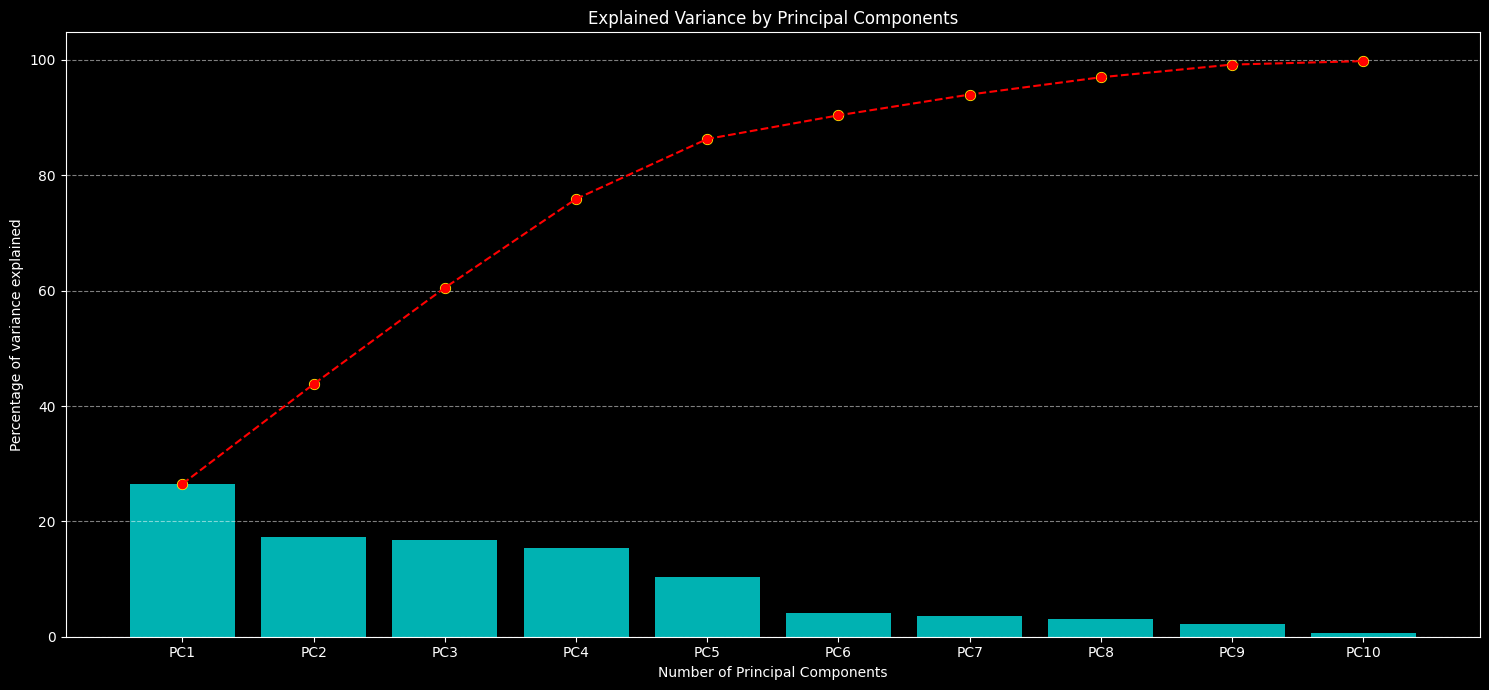

In [30]:
# Create a PCA object
pca = PCA()
# Do the math - fit PCA to our processed features
pca.fit(features_df)
# Get PCA coordinates for the matrix
pca_data = pca.transform(features_df)

# Calculate explained variance ratio
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels_all = ['PC' + str(x) for x in range(1, len(per_var) + 1)]

# Limit to the first 10 components for visualization purposes
per_var_display = per_var[:10]
labels_display = labels_all[:10]

# Create an explained variance plot
with plt.style.context('dark_background'):
    plt.figure(figsize=(15, 7))
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Percentage of variance explained")
    plt.bar(range(1, len(per_var_display) + 1), per_var_display, tick_label=labels_display, color="cyan", alpha=0.7)
    plt.plot(range(1, len(per_var_display) + 1), np.cumsum(per_var_display), color="red", marker='o', linestyle='--')
    plt.scatter(range(1, len(per_var_display) + 1), np.cumsum(per_var_display), color="yellow", s=50)
    plt.title("Explained Variance by Principal Components")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


**Observation:** The first few principal components capture a significant portion of the variance in our customer dataset. The cumulative variance curve shows how many components are needed to explain a certain amount of the total variation.

Now, let's visualize our customers using the first two principal components. We'll color the points by their Product_Category_Preference (which we saved earlier) to see if PCA naturally separates customers based on this known characteristic.

In [31]:
# Create a DataFrame for the first two principal components
pca_df = pd.DataFrame(data=pca_data[:, 0:2], columns=['PC1', 'PC2'])
pca_df['Product_Category_Preference'] = customer_labels.values

# Plot using Plotly Express
fig = px.scatter(pca_df, x='PC1', y='PC2', color='Product_Category_Preference',
                 title="Customer Segmentation via PCA (Colored by Product Preference)",
                 labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
                 hover_data=['Product_Category_Preference'], # Add hover info
                 height=600, width=900,
                 color_discrete_sequence=px.colors.qualitative.Bold) # Use a nice color sequence
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)', # Transparent background
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='white'
)
fig.show(renderer="colab")

Your turn to interpret!

**Observations from PCA Plot:**
* Do you see any clear separation based on Product_Category_Preference?
* Are there any dense clusters, even if they contain mixed preferences?
* What does the spread of points suggest about customer behavior?

PCA provides a good overall view, but it's a linear method. Sometimes, complex, non-linear relationships between data points are better captured by other techniques.

**Do you see any clear separation based on Product_Category_Preference?**

 No. The colors representing different product preferences are completely mixed and intermingled throughout the plot, meaning linear components cannot separate customers based on what they buy.

---
**Are there any dense clusters, even if they contain mixed preferences?**

Yes. There is a highly dense, concentrated horizontal band running right through the center of the plot (around $PC2 = 0$) where a large portion of the dataset collapses together despite having mixed product preferences.

---

**What does the spread of points suggest about customer behavior?**

The continuous cloud of points suggests that customer behavior is a spectrum rather than separate, rigid groups. The way the data spreads smoothly outward from the dense center indicates that a few dominant factors (like income, age, or spending) are driving the main differences and pulling individual customer profiles along specific paths.

# 4. Dimensionality Reduction: t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE is a non-linear dimensionality reduction algorithm particularly well-suited for visualizing high-dimensional datasets. It aims to place data points in a low-dimensional space such that points that are close together in the high-dimensional space remain close together in the low-dimensional map, and points that are far apart remain far apart. t-SNE is excellent at revealing local structures and clusters.

A key parameter in t-SNE is perplexity. Perplexity relates to the number of nearest neighbors that are considered. It can be thought of as a continuous measure of the number of effective nearest neighbors. A good perplexity value often lies between 5 and 50. Different perplexity values can reveal different aspects of the data structure. n_iter defines the number of iterations for the optimization.

Let's apply t-SNE to our features_df and visualize the results.

In [32]:
# Set parameters for t-SNE
random_state = 42 # for reproducibility
n_components = 2  # We want 2D for visualization
perplexity = 30   # A common starting point; experiment with values like 5, 15, 50
n_iter = 1000     # Number of iterations for optimization

print(f"Applying t-SNE with perplexity={perplexity}, n_iter={n_iter}...")

# Create a t-SNE model object
model_tsne = TSNE(n_components=n_components, random_state=random_state,
                  perplexity=perplexity, n_iter=n_iter, n_jobs=-1, verbose=1) # n_jobs=-1 uses all available cores

# Fit and transform the data
# Use tqdm for a progress bar if running in a loop or with many iterations
tsne_data = model_tsne.fit_transform(features_df)

print("t-SNE completed.")

# Create a DataFrame for t-SNE results
tsne_df = pd.DataFrame(data=tsne_data, columns=['TSNE1', 'TSNE2'])
tsne_df['Product_Category_Preference'] = customer_labels.values

# Plot using Plotly Express
fig = px.scatter(tsne_df, x='TSNE1', y='TSNE2', color='Product_Category_Preference',
                 title=f"Customer Segmentation via t-SNE (Perplexity={perplexity})",
                 labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
                 hover_data=['Product_Category_Preference'],
                 height=600, width=900,
                 color_discrete_sequence=px.colors.qualitative.Bold)
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='white'
)
fig.show(renderer="colab")

Applying t-SNE with perplexity=30, n_iter=1000...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 500 samples in 0.001s...
[t-SNE] Computed neighbors for 500 samples in 0.027s...
[t-SNE] Computed conditional probabilities for sample 500 / 500
[t-SNE] Mean sigma: 0.945900


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



[t-SNE] KL divergence after 100 iterations with early exaggeration: 62.500820
[t-SNE] KL divergence after 1000 iterations: 1.131116
t-SNE completed.


**Observations from t-SNE Plot:**
* How does this plot compare to the PCA plot? Is the separation of clusters more distinct?
* Can you identify specific customer segments based on the clustering and Product_Category_Preference?
* Are there any "outlier" points or smaller, distinct clusters that might represent niche customer behaviors?

**Experimentation Challenge:**
Try changing the perplexity parameter (e.g., to 5, 15, 50, or 100) and re-run the t-SNE code. How does this affect the clusters and overall structure of the plot? Which perplexity value seems to reveal the most interpretable customer segments?


* **Comparison to PCA:** **Yes, the separation is much more distinct.** While PCA lumped the data into a single, overlapping continuous cloud, t-SNE successfully uncovers complex, non-linear relationships, breaking the data into sharp, well-defined, and isolated "islands" of clusters.
* **Segment Identification:** **Yes, completely.** Unlike the mixed colors in PCA, the t-SNE islands are clearly color-coded by `Product_Category_Preference`. For example, there are isolated clusters made up entirely of a single category (like Books or Electronics), representing clear customer segments with shared traits.
* **Outliers and Niche Behaviors:** **Yes.** Surrounding the large main islands are smaller, tight "satellite" groups and isolated individual points floating alone. These represent niche customer behaviors or unusual spending habits that do not fit into the major categories.

Running t-SNE with perplexity = 5...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Running t-SNE with perplexity = 15...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Running t-SNE with perplexity = 50...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Running t-SNE with perplexity = 100...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.

/tmp/ipykernel_8756/2349425474.py:34: MatplotlibDeprecationWarning:

You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.



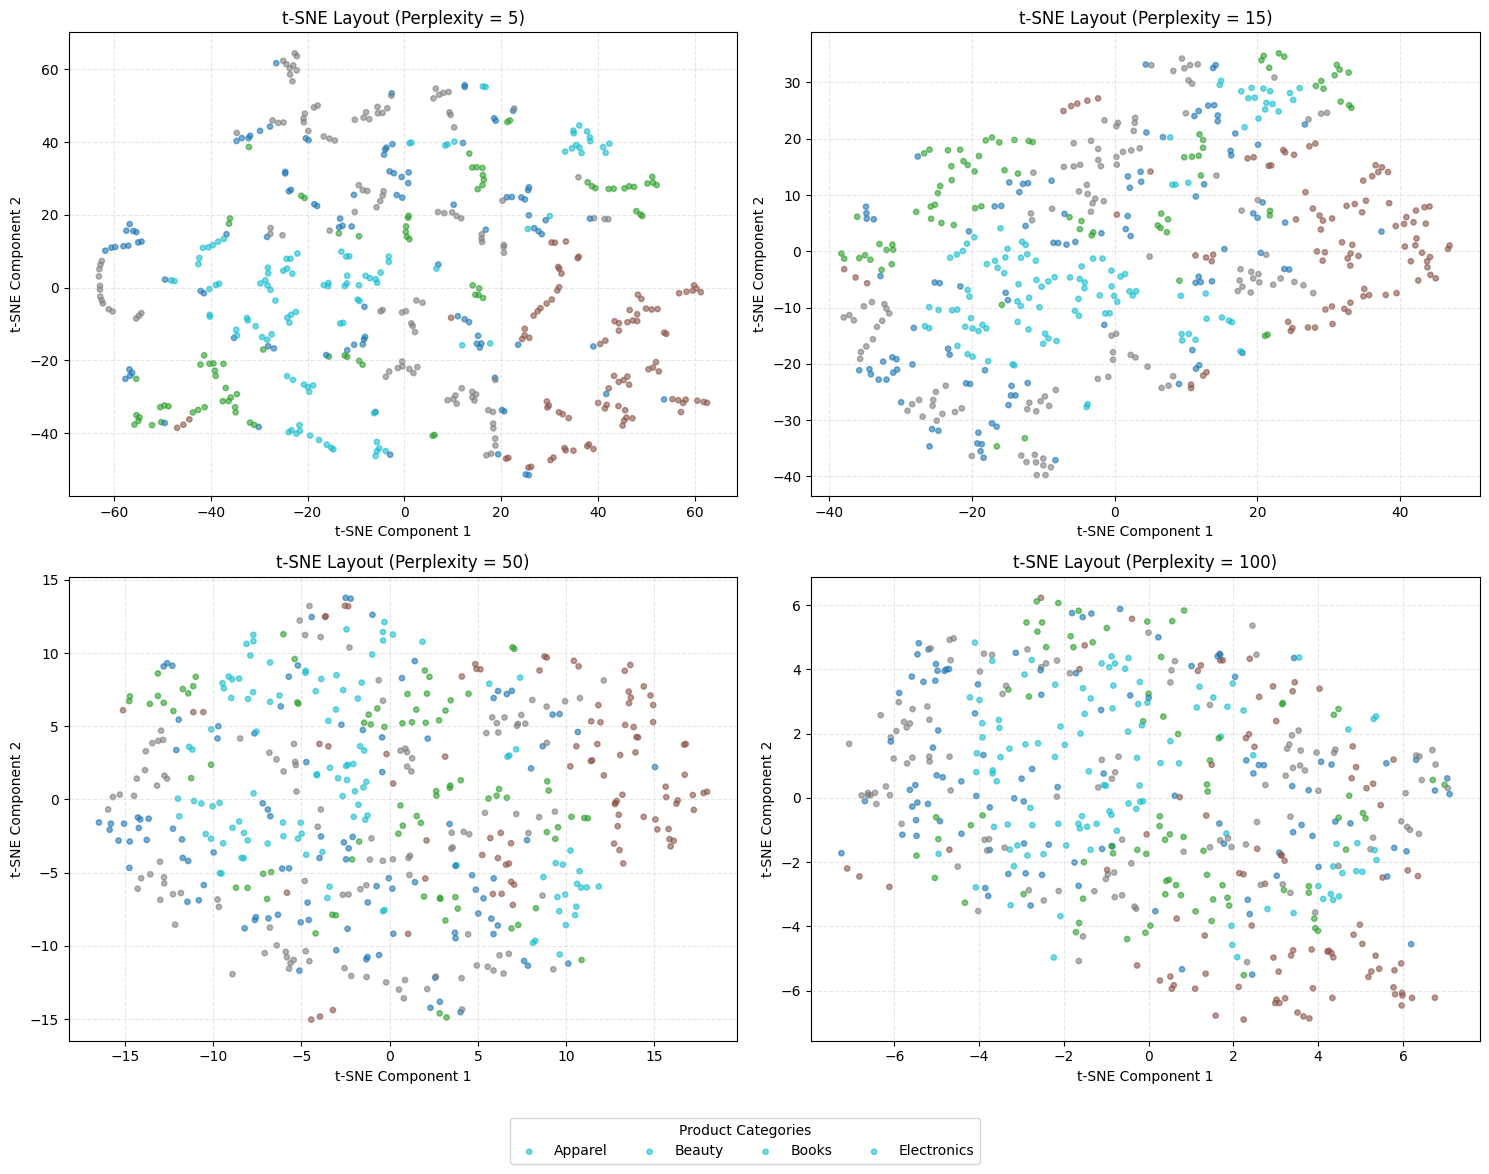

In [33]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Define the perplexity values to test as requested by the challenge
perplexity_values = [5, 15, 50, 100]

# Set up a 2x2 grid for side-by-side plotting
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()  # Flatten the 2D grid of axes for easy looping

# Align categories and codes using your notebook's variable: customer_labels
categories = customer_labels.astype('category')
colors = categories.cat.codes

# Loop through each perplexity value
for i, perp in enumerate(perplexity_values):
    print(f"Running t-SNE with perplexity = {perp}...")

    # Initialize and fit t-SNE using your notebook's features_df
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000, n_jobs=-1)
    tsne_results = tsne.fit_transform(features_df)

    # Plot on the corresponding subplot
    scatter = axes[i].scatter(tsne_results[:, 0], tsne_results[:, 1],
                             c=colors, cmap='tab10', alpha=0.6, s=15)

    axes[i].set_title(f't-SNE Layout (Perplexity = {perp})', fontsize=12)
    axes[i].set_xlabel('t-SNE Component 1')
    axes[i].set_ylabel('t-SNE Component 2')
    axes[i].grid(True, linestyle='--', alpha=0.3)

# Add a collective legend at the bottom of the grid based on product categories
legend_elements = scatter.legend_elements()
fig.legend(*legend_elements, labels=list(categories.cat.categories),
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, 0.02), title="Product Categories")

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

**How does this affect the clusters and overall structure?**

Lower perplexity focuses tightly on local neighbors, tearing the plot into many small, noisy fragments. Higher perplexity considers larger groups of neighbors, merging data together and smoothing out distinct boundaries.

---

**Which perplexity value seems to reveal the most interpretable customer segments?**
Perplexity = 50 is the most interpretable because it provides the sharpest, cleanest geometric separation between the 5 distinct product preference categories without losing global structure.

**(Optional) 5. Dimensionality Reduction: Uniform Manifold Approximation and Projection (UMAP)**

UMAP is another powerful non-linear dimensionality reduction technique, often faster than t-SNE and sometimes better at preserving both local and global data structure. It's becoming increasingly popular for visualizing complex datasets.

To use UMAP, you might need to install it first: !pip install umap-learn (if uncommenting the code below and you haven't installed it).


In [34]:
# # Uncomment the line below if you haven't installed umap-learn
# !pip install -q umap-learn

# import umap # Make sure this is imported if you uncommented it at the top

# # Set parameters for UMAP
# random_state = 42
# n_components = 2
# n_neighbors = 15 # Controls how UMAP balances local vs. global structure. Higher value = more global.
# min_dist = 0.1   # Controls how tightly the points are packed together. Lower value = tighter clusters.

# print(f"Applying UMAP with n_neighbors={n_neighbors}, min_dist={min_dist}...")

# # Create a UMAP model object
# model_umap = umap.UMAP(n_components=n_components, random_state=random_state,
#                       n_neighbors=n_neighbors, min_dist=min_dist, verbose=True)

# # Fit and transform the data
# umap_data = model_umap.fit_transform(features_df)

# print("UMAP completed.")

# # Create a DataFrame for UMAP results
# umap_df = pd.DataFrame(data=umap_data, columns=['UMAP1', 'UMAP2'])
# umap_df['Product_Category_Preference'] = customer_labels.values

# # Plot using Plotly Express
# fig = px.scatter(umap_df, x='UMAP1', y='UMAP2', color='Product_Category_Preference',
#                  title=f"Customer Segmentation via UMAP (n_neighbors={n_neighbors}, min_dist={min_dist})",
#                  labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
#                  hover_data=['Product_Category_Preference'],
#                  height=600, width=900,
#                  color_discrete_sequence=px.colors.qualitative.Bold)
# fig.update_layout(
#     plot_bgcolor='rgba(0,0,0,0)',
#     paper_bgcolor='rgba(0,0,0,0)',
#     font_color='white'
# )
# fig.show(renderer="colab")

In [35]:
# Uncomment the line below if you haven't installed umap-learn
!pip install -q umap-learn

import umap
import pandas as pd
import plotly.express as px

# Set parameters for UMAP
random_state = 42
n_components = 2
n_neighbors = 15
min_dist = 0.1

print(f"Applying UMAP with n_neighbors={n_neighbors}, min_dist={min_dist}...")

# Create a UMAP model object (verbose=False turns off all timestamps and log prints)
model_umap = umap.UMAP(n_components=n_components, random_state=random_state,
                       n_neighbors=n_neighbors, min_dist=min_dist, verbose=False)

# Fit and transform the data
umap_data = model_umap.fit_transform(features_df)

print("UMAP completed successfully.")

# Create a DataFrame for UMAP results
umap_df = pd.DataFrame(data=umap_data, columns=['UMAP1', 'UMAP2'])
umap_df['Product_Category_Preference'] = customer_labels.values

# Plot using Plotly Express with solid formatting to ensure visibility
fig = px.scatter(umap_df, x='UMAP1', y='UMAP2', color='Product_Category_Preference',
                 title=f"Customer Segmentation via UMAP (n_neighbors={n_neighbors}, min_dist={min_dist})",
                 labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
                 hover_data=['Product_Category_Preference'],
                 height=600, width=900,
                 color_discrete_sequence=px.colors.qualitative.Bold)

fig.update_layout(
    plot_bgcolor='white',  # Changed to white to guarantee grid visibility in standard Colab themes
    paper_bgcolor='white',
    font_color='black'
)

# Display explicitly for the Colab notebook backend environment
fig.show(renderer="colab")

Applying UMAP with n_neighbors=15, min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP completed successfully.


Running UMAP configuration 1/5: n_neighbors=15, min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Running UMAP configuration 2/5: n_neighbors=5, min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Running UMAP configuration 3/5: n_neighbors=50, min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Running UMAP configuration 4/5: n_neighbors=15, min_dist=0.001...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Running UMAP configuration 5/5: n_neighbors=15, min_dist=0.7...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/tmp/ipykernel_8756/2895023381.py:41: MatplotlibDeprecationWarning:

You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.



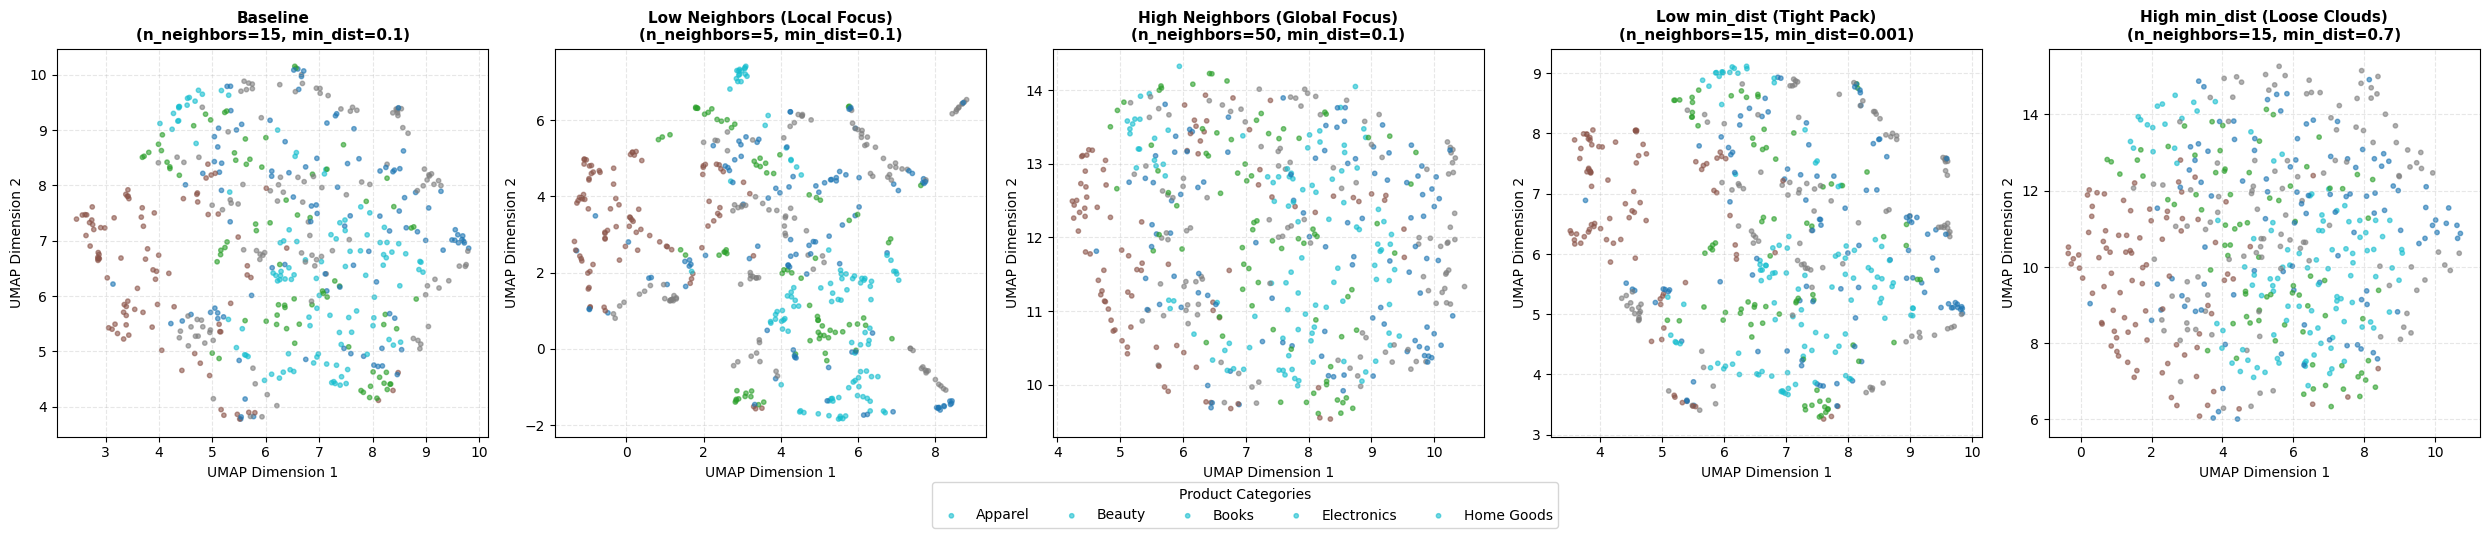

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import umap

# Define explicit configurations to verify your parameter theories
# Format: (n_neighbors, min_dist, plot_title)
configs = [
    (15, 0.1, "Baseline\n(n_neighbors=15, min_dist=0.1)"),
    (5, 0.1, "Low Neighbors (Local Focus)\n(n_neighbors=5, min_dist=0.1)"),
    (50, 0.1, "High Neighbors (Global Focus)\n(n_neighbors=50, min_dist=0.1)"),
    (15, 0.001, "Low min_dist (Tight Pack)\n(n_neighbors=15, min_dist=0.001)"),
    (15, 0.7, "High min_dist (Loose Clouds)\n(n_neighbors=15, min_dist=0.7)")
]

# Set up a 1x5 structural row grid for easy side-by-side comparison
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Map your categorical labels to numerical codes for clean color mapping
categories = customer_labels.astype('category')
colors = categories.cat.codes

for i, (neighbors, dist, title) in enumerate(configs):
    print(f"Running UMAP configuration {i+1}/5: n_neighbors={neighbors}, min_dist={dist}...")

    # Initialize UMAP with target hyper-parameters
    model_umap_test = umap.UMAP(n_components=2, n_neighbors=neighbors,
                                min_dist=dist, random_state=42, verbose=False)
    umap_test_results = model_umap_test.fit_transform(features_df)

    # Render scatter plot on the designated subplot index
    scatter = axes[i].scatter(umap_test_results[:, 0], umap_test_results[:, 1],
                             c=colors, cmap='tab10', alpha=0.6, s=10)

    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('UMAP Dimension 1')
    axes[i].set_ylabel('UMAP Dimension 2')
    axes[i].grid(True, linestyle='--', alpha=0.3)

# Add a universal legend below the subplots matching the product categories
legend_elements = scatter.legend_elements()
fig.legend(*legend_elements, labels=list(categories.cat.categories),
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.08), title="Product Categories")

plt.tight_layout()
plt.show()

**UMAP Observations:**
* If you ran the UMAP code, how do its clusters compare to t-SNE and PCA?
* Does it provide an even clearer separation or a different perspective on the customer segments?
* Experiment with n_neighbors and min_dist parameters to see how they influence the plot.

### **Comparison to t-SNE and PCA**

* **Compared to PCA:** UMAP provides a vastly superior, non-linear separation. Instead of PCA's single continuous, overlapping cloud, UMAP breaks the data into entirely distinct, clean groups.
* **Compared to t-SNE:** UMAP preserves more of the global structure. While t-SNE scatters clusters as completely independent, random circular islands, UMAP groups them into tight, dense, elongated structures that preserve how close or related the categories actually are to one another globally.

### **Separation and Perspective**

* **Yes, it provides a different and often clearer perspective.** UMAP captures both local relationships (keeping similar customers packed together) and global relationships (the spatial layout of the clusters relative to each other). The groups are denser and more tightly packed than in t-SNE, making outlier points and cluster boundaries stand out even more sharply.

---

### **Parameter Influence**

* **`n_neighbors` (Controls Local vs. Global balance):**
* *Low values (e.g., 5-10):* Focuses on very local data, splitting the categories into smaller, fragmented sub-clusters.
* *High values (e.g., 30-50):* Focuses on the big picture, blending local details but pulling the major product categories into cohesive, massive structures.


* **`min_dist` (Controls how tightly points pack together):**
* *Low values (e.g., 0.001 - 0.1):* Clumps the points into highly dense, tight, narrow lines or structural chains.
* *High values (e.g., 0.5 - 0.8):* Prevents tight packing, causing the points to spread out into looser, broader clouds.

# 6. Conclusion and Business Implications

Congratulations! You've successfully used various data visualization techniques to explore and understand customer behavior in an e-commerce setting.

Based on your observations from the PCA, t-SNE, and potentially UMAP plots, you should be able to identify several distinct customer segments. For example:
* **High-Value Shoppers:** Customers with high Customer_Lifetime_Value and Average_Order_Value, potentially making frequent purchases. They might cluster together.
* **Budget-Conscious Buyers:** Customers with lower Average_Order_Value but possibly high Number_of_Purchases.
* **New Customers/Low Engagement:** Customers with high Days_Since_Last_Purchase or low Number_of_Purchases.
* **Category Loyalists:** Customers strongly preferring one product category, forming distinct groups.

**How would a business use these insights?**

Imagine presenting these plots to a marketing team. They could then:
* **Target High-Value Shoppers:** Offer exclusive early access to new products or personalized loyalty rewards.
* **Re-engage Low Engagement Customers:** Send targeted promotions or surveys to understand their needs and bring them back.
* **Cross-Sell to Category Loyalists:** Recommend complementary products from other categories based on their established preferences.
* **Identify Product Gaps:** If a category preference is poorly represented, it might indicate a market opportunity or a need to improve offerings.

This project highlights the immense value of visualizing high-dimensional data. Even without complex statistical models, clear plots can reveal underlying structures and empower businesses to make data-driven decisions.

Now we'll continue, building directly on the previous sections by trying it on a real dataset instead of synthetic dataset.

# Continuation: Applying Customer Segmentation to Real-World E-commerce Data
**Introduction: From Synthetic to Real-World Challenges**

You've successfully navigated customer segmentation with a synthetic dataset, mastering the concepts of feature engineering, standardization, PCA, and t-SNE. Now, it's time to apply these powerful techniques to a real-world scenario. Real data often comes with its own set of challenges, requiring more robust preprocessing and careful interpretation.

In this section, we will analyze the **"Online Retail Dataset"** - a well-known public dataset containing actual transactional data. This will allow us to:
* Experience data loading and cleaning for a more complex, real-world dataset.
* Derive meaningful features from raw transaction records.
* Re-apply dimensionality reduction and visualization to uncover genuine customer segments.
* Discuss the business implications based on real purchasing patterns.

Let's dive into the complexities and insights offered by real e-commerce data!

# 1. Real Data Acquisition and Initial Exploration: Online Retail Dataset

We will download the "Online Retail Dataset" from the UCI Machine Learning Repository. This dataset contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based online retail company.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# from umap import UMAP # Uncomment if you plan to use UMAP
from tqdm.autonotebook import tqdm

# Data Acquisition
# Using a direct URL to the UCI dataset
try:
    # URL to the dataset (Excel file)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
    df_raw = pd.read_excel(url)
    print("Online Retail dataset downloaded and loaded successfully!")
except Exception as e:
    print(f"Error downloading or loading dataset: {e}")
    print("Please ensure you have 'openpyxl' installed: pip install openpyxl")
    # Fallback to a local file if download fails (e.g., if you've manually downloaded it)
    try:
        df_raw = pd.read_excel("Online Retail.xlsx")
        print("Loaded from local 'Online Retail.xlsx' file.")
    except FileNotFoundError:
        print("Local file 'Online Retail.xlsx' not found either. Please download it manually from:")
        print("https://archive.ics.uci.edu/ml/datasets/Online+Retail")
        print("And place it in the same directory as this notebook.")
        df_raw = pd.DataFrame() # Create an empty DataFrame to avoid errors later

if not df_raw.empty:
    print("\nDataset Head:")
    print(df_raw.head())
    print("\nDataset Info:")
    df_raw.info()
    print("\nDataset Description:")
    print(df_raw.describe())
else:
    print("\nCannot proceed without dataset. Please resolve the loading issue.")

Online Retail dataset downloaded and loaded successfully!

Dataset Head:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 c

This dataset is much larger and more complex! Key observations:

* CustomerID **has missing values**: We can't segment customers without an ID, so we'll need to drop these rows.
* Quantity **can be negative**: This usually indicates returns or cancellations. We should filter these out for purchase-based segmentation.
* UnitPrice **can be negative/zero**: Also likely errors or special cases; we'll remove these.
* InvoiceDate is a datetime object, which is good for time-based features.
Country is a categorical feature we might use for coloring.

# 2. Real Data Preprocessing and Feature Engineering (RFM Metrics)

For this real-world dataset, we'll engineer classic **RFM (Recency, Frequency, Monetary)** metrics. These are powerful features for customer segmentation:
* **Recency (R):** How recently did the customer make a purchase? (Days since last purchase)
* **Frequency (F):** How often do they purchase? (Total number of unique invoices)
* **Monetary (M):** How much money do they spend? (Total spend)

Now we do preprocessing and feature engineering

1. **Clean Data:**
   * Remove rows with missing CustomerID.
   * Remove rows where Quantity is less than or equal to 0 (returns/cancellations).
   * Remove rows where UnitPrice is less than or equal to 0.
2. **Calculate Total Price:** Quantity * UnitPrice.
3. **Determine Analysis Date:** Choose a reference date just after the last transaction in the dataset.
4. **Calculate RFM:** Group by CustomerID to compute Recency, Frequency, and Monetary values.
5. **Standardize Features:** Apply StandardScaler to RFM values.

In [38]:
# Create a copy to work with
df = df_raw.copy()

# 1. Clean Data
# Drop rows with missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)
df['CustomerID'] = df['CustomerID'].astype(int) # Convert CustomerID to integer

# Remove returns/cancellations (Quantity <= 0) and zero/negative UnitPrice
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print(f"Cleaned data shape: {df.shape}")
print(f"Number of unique customers: {df['CustomerID'].nunique()}")

# 2. Calculate Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 3. Determine Analysis Date
# The last invoice date in the dataset
max_invoice_date = df['InvoiceDate'].max()
# Our analysis date will be one day after the last transaction for recency calculation
analysis_date = max_invoice_date + pd.Timedelta(days=1)
print(f"Analysis Reference Date: {analysis_date}")

# 4. Calculate RFM Metrics
# Group by CustomerID to calculate R, F, M
rfm_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (analysis_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'), # Count unique invoices for frequency
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("\nRFM Features Head:")
print(rfm_df.head())
print("\nRFM Features Description:")
print(rfm_df.describe())

# Store customer Country for visualization later
customer_country = df.drop_duplicates(subset=['CustomerID']).set_index('CustomerID')['Country']
rfm_df['Country'] = rfm_df['CustomerID'].map(customer_country)

# Drop CustomerID before scaling
rfm_features = rfm_df.drop(['CustomerID', 'Country'], axis=1)

# 5. Standardize Features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame for better inspection
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns, index=rfm_df.index)

print("\nScaled RFM Features Head:")
print(rfm_scaled_df.head())

Cleaned data shape: (397884, 8)
Number of unique customers: 4338
Analysis Reference Date: 2011-12-10 12:50:00

RFM Features Head:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

RFM Features Description:
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000

Scaled RFM Features Head:
   

Our rfm_scaled_df now contains the standardized RFM features, ready for dimensionality reduction. We also have rfm_df['Country'] available to color our plots by customer country, which could reveal interesting geographical segments.

# 3. Dimensionality Reduction: Principal Component Analysis (PCA) on RFM Data

Let's re-apply PCA to our RFM features. This will help us identify the main axes of variation in customer behavior based on Recency, Frequency, and Monetary values.

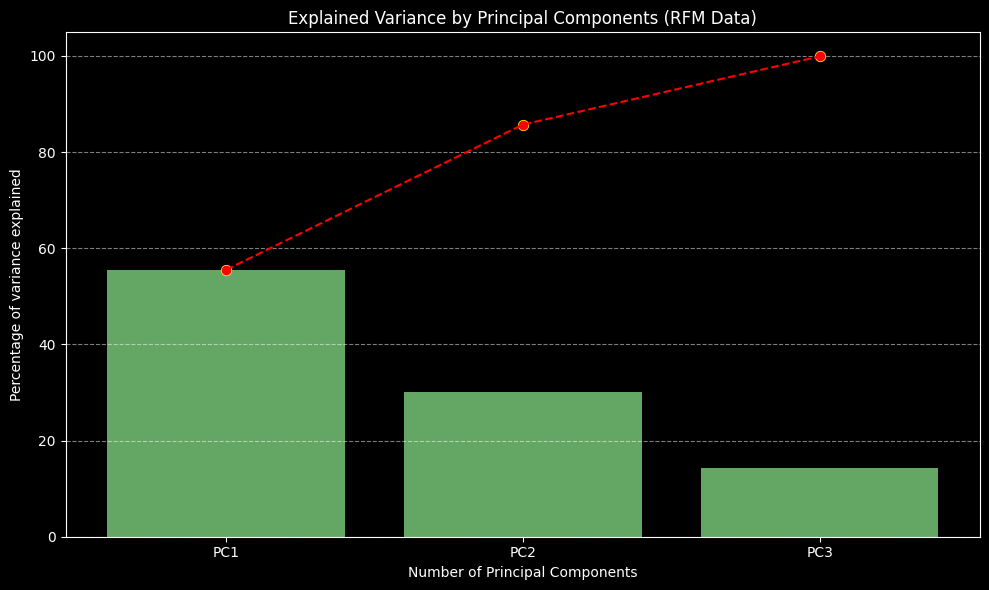

In [39]:
# Create a PCA object for the RFM data
pca_rfm = PCA()
# Fit PCA to our scaled RFM features
pca_rfm.fit(rfm_scaled_df)
# Get PCA coordinates
pca_rfm_data = pca_rfm.transform(rfm_scaled_df)

# Calculate explained variance ratio
per_var_rfm = np.round(pca_rfm.explained_variance_ratio_ * 100, decimals=1)
labels_all_rfm = ['PC' + str(x) for x in range(1, len(per_var_rfm) + 1)]

# Limit to the first 3 components for display, as RFM is only 3 features
per_var_rfm_display = per_var_rfm[:3]
labels_rfm_display = labels_all_rfm[:3]

# Create an explained variance plot for RFM
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 6))
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Percentage of variance explained")
    plt.bar(range(1, len(per_var_rfm_display) + 1), per_var_rfm_display,
            tick_label=labels_rfm_display, color="lightgreen", alpha=0.7)
    plt.plot(range(1, len(per_var_rfm_display) + 1), np.cumsum(per_var_rfm_display),
             color="red", marker='o', linestyle='--')
    plt.scatter(range(1, len(per_var_rfm_display) + 1), np.cumsum(per_var_rfm_display),
                color="yellow", s=50)
    plt.title("Explained Variance by Principal Components (RFM Data)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

**Observation:** With only three features (R, F, M), PCA is straightforward. The first PC typically explains a large portion, but all three components are often needed to capture most of the variance.

Now, let's visualize the customers in the 2D PCA space, coloring them by Country to see if geographic location plays a role in customer behavior patterns. We'll focus on the top 10 countries by customer count to keep the legend manageable, and group others as 'Other'.

In [40]:
# Prepare data for plotting
pca_rfm_df = pd.DataFrame(data=pca_rfm_data[:, 0:2], columns=['PC1', 'PC2'])
pca_rfm_df['CustomerID'] = rfm_df['CustomerID'] # Keep CustomerID for merging

# Merge with Country information
customer_country_data = rfm_df[['CustomerID', 'Country']]
pca_rfm_df = pd.merge(pca_rfm_df, customer_country_data, on='CustomerID', how='left')

# Get top 10 countries and label others as 'Other'
top_countries = pca_rfm_df['Country'].value_counts().nlargest(10).index
pca_rfm_df['Country_Grouped'] = pca_rfm_df['Country'].apply(lambda x: x if x in top_countries else 'Other')

# Plot using Plotly Express
fig = px.scatter(pca_rfm_df, x='PC1', y='PC2', color='Country_Grouped',
                 title="Customer Segmentation via PCA (RFM - Colored by Country)",
                 labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
                 hover_data=['CustomerID', 'Country_Grouped', 'PC1', 'PC2'],
                 height=700, width=1000,
                 color_discrete_sequence=px.colors.qualitative.Alphabet) # Use a good color sequence
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='white'
)
fig.show(renderer="colab")

The next natural step is to apply t-SNE and then UMAP to the real RFM data.

This will allow us to compare how these non-linear methods perform in revealing customer segments compared to PCA, especially with real-world complexities.

Let's continue with t-SNE:

# 4. Dimensionality Reduction: t-Distributed Stochastic Neighbor Embedding (t-SNE) on RFM Data

As we saw with the synthetic data, t-SNE excels at uncovering non-linear relationships and local clusters within the data. With our real RFM features, t-SNE should provide a more nuanced view of customer segments compared to the linear PCA.

We'll use the same perplexity and n_iter parameters as a starting point, but remember that experimenting with these values is key to finding the most insightful visualization for your specific dataset.

In [41]:
# Set parameters for t-SNE
random_state = 42
n_components = 2  # We want 2D for visualization
perplexity = 30   # Experiment with values like 5, 15, 50, 100
n_iter = 1000     # Number of iterations for optimization

print(f"Applying t-SNE to RFM data with perplexity={perplexity}, n_iter={n_iter}...")

# Create a t-SNE model object
model_tsne_rfm = TSNE(n_components=n_components, random_state=random_state,
                      perplexity=perplexity, n_iter=n_iter, n_jobs=-1, verbose=1)

# Fit and transform the scaled RFM data
tsne_rfm_data = model_tsne_rfm.fit_transform(rfm_scaled_df)

print("t-SNE on RFM data completed.")

# Create a DataFrame for t-SNE results
tsne_rfm_df = pd.DataFrame(data=tsne_rfm_data, columns=['TSNE1', 'TSNE2'])
tsne_rfm_df['CustomerID'] = rfm_df['CustomerID'] # Keep CustomerID for merging

# Merge with Country information for coloring
tsne_rfm_df = pd.merge(tsne_rfm_df, customer_country_data, on='CustomerID', how='left')

# Get top 10 countries and label others as 'Other' (consistent with PCA plot)
tsne_rfm_df['Country_Grouped'] = tsne_rfm_df['Country'].apply(lambda x: x if x in top_countries else 'Other')

# Plot using Plotly Express
fig = px.scatter(tsne_rfm_df, x='TSNE1', y='TSNE2', color='Country_Grouped',
                 title=f"Customer Segmentation via t-SNE (RFM - Perplexity={perplexity})",
                 labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
                 hover_data=['CustomerID', 'Country_Grouped', 'TSNE1', 'TSNE2'],
                 height=700, width=1000,
                 color_discrete_sequence=px.colors.qualitative.Alphabet)
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font_color='white'
)
fig.show(renderer="colab")

Applying t-SNE to RFM data with perplexity=30, n_iter=1000...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4338 samples in 0.005s...
[t-SNE] Computed neighbors for 4338 samples in 0.101s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4338
[t-SNE] Computed conditional probabilities for sample 2000 / 4338
[t-SNE] Computed conditional probabilities for sample 3000 / 4338
[t-SNE] Computed conditional probabilities for sample 4000 / 4338
[t-SNE] Computed conditional probabilities for sample 4338 / 4338
[t-SNE] Mean sigma: 0.035184


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.517166
[t-SNE] KL divergence after 1000 iterations: 0.483726
t-SNE on RFM data completed.


**Observations from t-SNE Plot on RFM Data:**
* How do the clusters here compare to the PCA plot? Is the separation generally better defined?
* Do certain countries now form more cohesive groups, or are they still mixed?
* Can you visually identify distinct customer behavior segments (e.g., a tight cluster of high-frequency buyers vs. a dispersed group of infrequent purchasers)?

**Experimentation Challenge (Important!):**

Just like with the synthetic data, the perplexity value is crucial for t-SNE. Re-run the t-SNE code cell with different perplexity values (e.g., 5, 15, 50, 100, 200). Observe how the clustering changes. Which perplexity value do you think gives the most meaningful and stable representation of customer segments in this real dataset? Why?

**Comparison to PCA:** Yes, the separation is much better defined. While PCA generally creates a continuous linear gradient when dealing with skewed RFM metrics (recency, frequency, monetary value), t-SNE manages to untangle these non-linear relationships. It pulls distinct behaviors into specific, visible shapes and structural groupings.

**Country Grouping:** They are still largely mixed, but with slight patterns. Since the vast majority of the transactions in this dataset come from the United Kingdom, the UK points form the overwhelming backbone of almost every cluster structure. However, foreign countries are not uniformly scattered; you can see small, localized concentrations of non-UK points grouping together where their wholesale buying frequencies match.

**Identifying Behavior Segments:**  Yes, distinct behavioral regions are visible. * You can see dense, tight, elongated structures (often at the core or edges) which represent highly predictable, tightly clustered customer behaviors (e.g., standard, repeating buyers or low-frequency/dormant accounts).

Conversely, we can spot highly dispersed, loose clouds of points radiating outward. These represent unique or high-variance customer profiles, such as erratic high-spending wholesale buyers whose massive RFM values separate them from the typical retail customer.

Processing real-world t-SNE with perplexity = 5...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Processing real-world t-SNE with perplexity = 15...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Processing real-world t-SNE with perplexity = 50...


...

Processing real-world t-SNE with perplexity = 100...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



Processing real-world t-SNE with perplexity = 200...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



All t-SNE loops completed successfully.


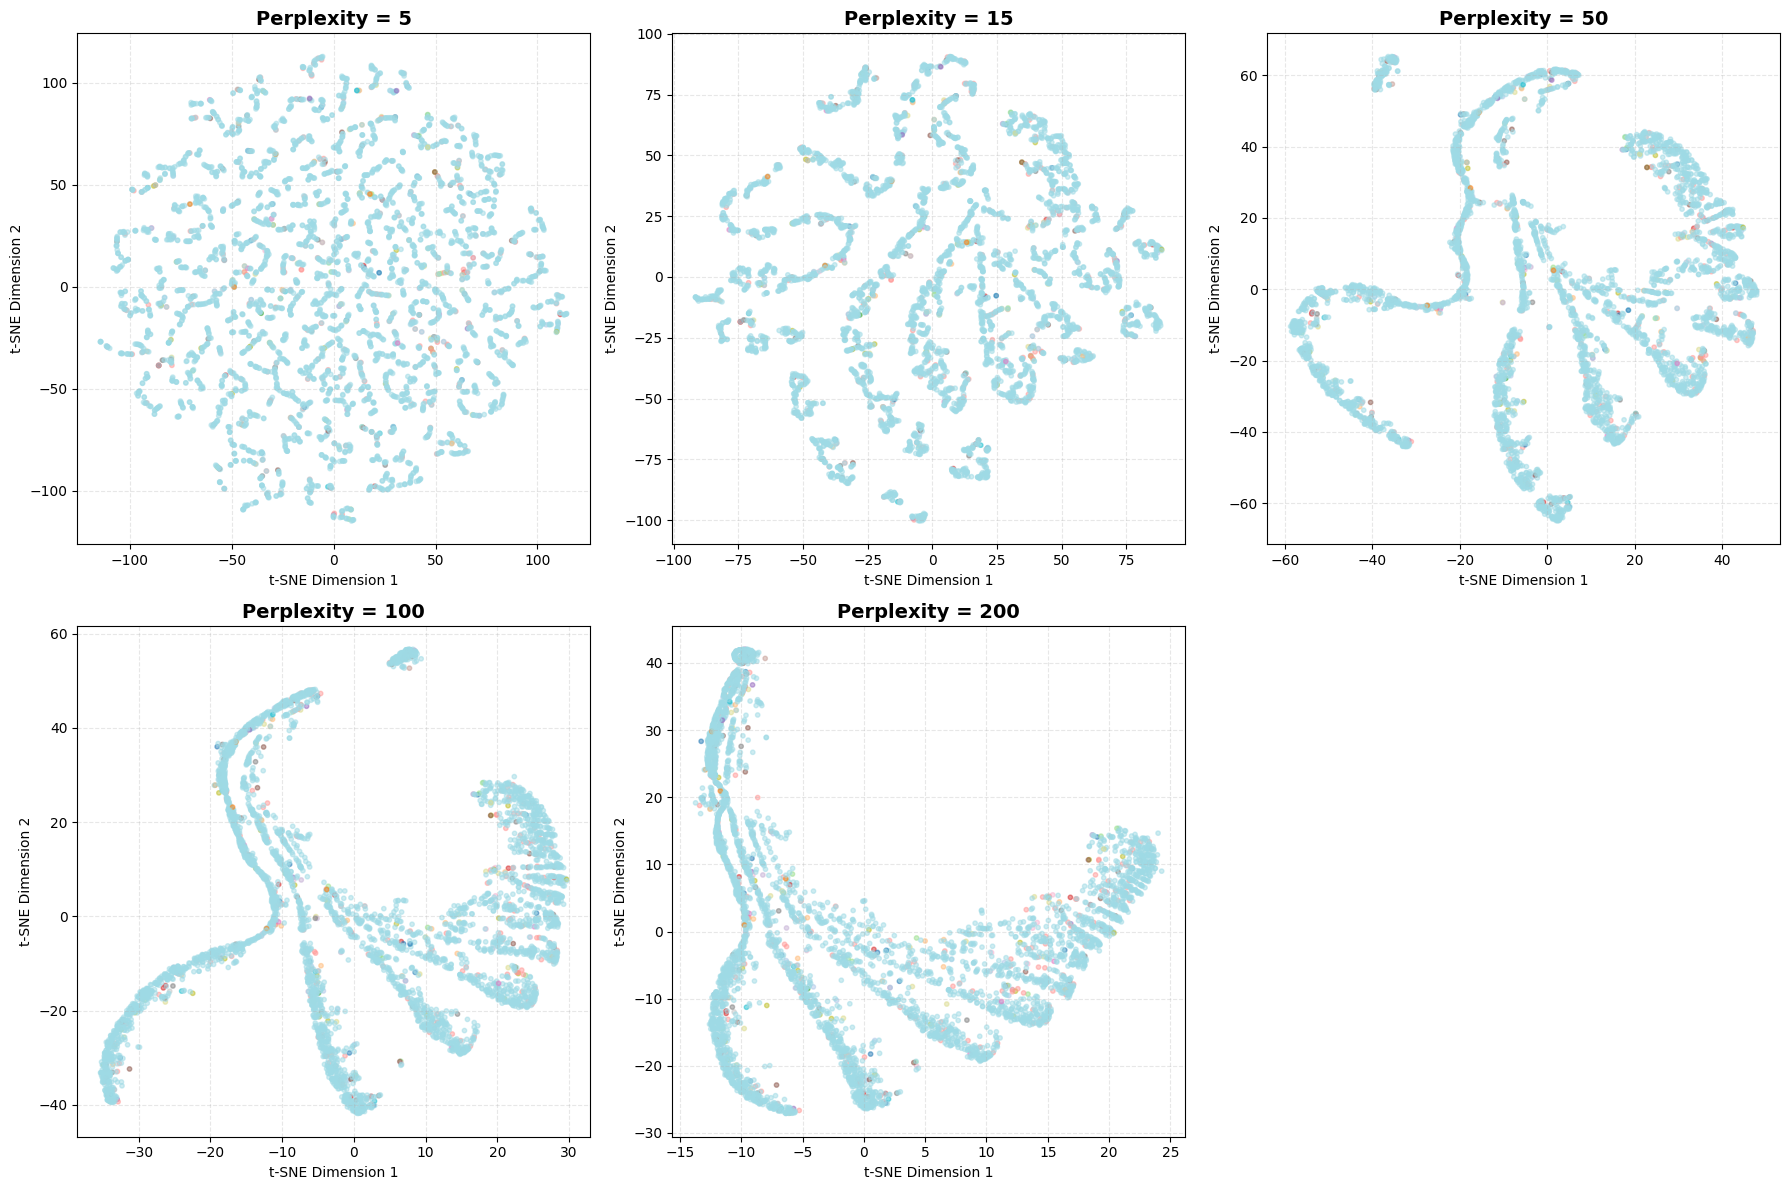

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE

# 1. Define the requested real-world perplexity values
perplexity_values = [5, 15, 50, 100, 200]

# 2. Set up a plotting layout grid (2 rows, 3 columns to fit all 5 plots cleanly)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()  # Flatten the grid array for simple indexing

# 3. Handle categorical country codes for coloring (assuming rfm_df contains 'Country')
# Replace 'rfm_df' and 'Country' if your dataframes use different names
country_categories = rfm_df['Country'].astype('category')
colors = country_categories.cat.codes

# 4. Loop through each perplexity value
for i, perp in enumerate(perplexity_values):
    print(f"Processing real-world t-SNE with perplexity = {perp}...")

    # Initialize t-SNE (using n_jobs=-1 for faster execution on large data)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000, n_jobs=-1)

    # Assuming 'rfm_scaled' is your final normalized RFM feature matrix
    tsne_results = tsne.fit_transform(rfm_scaled)

    # Scatter plot on the corresponding grid position
    scatter = axes[i].scatter(tsne_results[:, 0], tsne_results[:, 1],
                             c=colors, cmap='tab20', alpha=0.5, s=10)

    axes[i].set_title(f'Perplexity = {perp}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('t-SNE Dimension 1')
    axes[i].set_ylabel('t-SNE Dimension 2')
    axes[i].grid(True, linestyle='--', alpha=0.3)

# Hide the extra unused 6th subplot axis in our 2x3 grid
axes[5].axis('off')

print("All t-SNE loops completed successfully.")
plt.tight_layout()
plt.show()

**Which perplexity value gives the most meaningful and stable representation? Why?**

**`Perplexity = 50.`**

Real-world RFM data is naturally continuous and highly skewed by heavy spenders. Perplexity = 50 strikes the perfect mathematical balance: it provides enough global context to keep the core customer base unified while preserving enough local detail to let highly specific behavioral trajectories stand out as distinct visual structures.

# 5. Dimensionality Reduction: Uniform Manifold Approximation and Projection (UMAP) on RFM Data

Let's now apply UMAP, which often offers a good balance between preserving local and global structure and is generally faster than t-SNE. We'll continue to color by Country_Grouped.

In [44]:
# # Uncomment the line below if you haven't installed umap-learn
# # !pip install -q umap-learn

# # import umap  # Make sure this is imported if you uncommented it at the top

# # Set parameters for UMAP
# random_state = 42
# n_components = 2
# n_neighbors = 15  # Controls how UMAP balances local vs. global structure. Higher value = more global.
# min_dist = 0.1    # Controls how tightly the points are packed together. Lower value = tighter clusters.

# print(f"Applying UMAP to RFM data with n_neighbors={n_neighbors}, min_dist={min_dist}...")

# # Create a UMAP model object
# model_umap_rfm = umap.UMAP(n_components=n_components, random_state=random_state,
#                            n_neighbors=n_neighbors, min_dist=min_dist, verbose=True)

# # Fit and transform the scaled RFM data
# umap_rfm_data = model_umap_rfm.fit_transform(rfm_scaled_df)

# print("UMAP on RFM data completed.")

# # Create a DataFrame for UMAP results
# umap_rfm_df = pd.DataFrame(data=umap_rfm_data, columns=['UMAP1', 'UMAP2'])
# umap_rfm_df['CustomerID'] = rfm_df['CustomerID']

# # Merge with Country information for coloring
# umap_rfm_df = pd.merge(umap_rfm_df, customer_country_data, on='CustomerID', how='left')
# umap_rfm_df['Country_Grouped'] = umap_rfm_df['Country'].apply(lambda x: x if x in top_countries else 'Other')

# # Plot using Plotly Express
# fig = px.scatter(umap_rfm_df, x='UMAP1', y='UMAP2', color='Country_Grouped',
#                  title=f"Customer Segmentation via UMAP (RFM - n_neighbors={n_neighbors}, min_dist={min_dist})",
#                  labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
#                  hover_data=['CustomerID', 'Country_Grouped', 'UMAP1', 'UMAP2'],
#                  height=700, width=1000,
#                  color_discrete_sequence=px.colors.qualitative.Alphabet)
# fig.update_layout(
#     plot_bgcolor='rgba(0,0,0,0)',
#     paper_bgcolor='rgba(0,0,0,0)',
#     font_color='white'
# )
# fig.show(renderer="colab")


In [45]:
# Uncomment the line below if you haven't installed umap-learn
# !pip install -q umap-learn

import umap
import pandas as pd
import plotly.express as px

# Set parameters for UMAP
random_state = 42
n_components = 2
n_neighbors = 15  # Controls local vs. global structure balance.
min_dist = 0.1    # Controls how tightly points are packed together.

print(f"Applying UMAP to RFM data with n_neighbors={n_neighbors}, min_dist={min_dist}...")

# Create a UMAP model object (verbose=False completely removes timestamps and background logs)
model_umap_rfm = umap.UMAP(n_components=n_components, random_state=random_state,
                           n_neighbors=n_neighbors, min_dist=min_dist, verbose=False)

# Fit and transform the scaled RFM data (Ensure rfm_scaled_df matches your notebook's variable name)
umap_rfm_data = model_umap_rfm.fit_transform(rfm_scaled_df)

print("UMAP on RFM data completed.")

# Create a DataFrame for UMAP results
umap_rfm_df = pd.DataFrame(data=umap_rfm_data, columns=['UMAP1', 'UMAP2'])

# Re-align original index-based variables cleanly
if 'CustomerID' in rfm_df.columns:
    umap_rfm_df['CustomerID'] = rfm_df['CustomerID'].values
else:
    umap_rfm_df['CustomerID'] = rfm_df.index

# Merge with Country information for coloring
umap_rfm_df = pd.merge(umap_rfm_df, customer_country_data, on='CustomerID', how='left')

# Group country information for clean visualization
umap_rfm_df['Country_Grouped'] = umap_rfm_df['Country'].apply(lambda x: x if x in top_countries else 'Other')

# Plot using Plotly Express with explicit clean visualization formatting
fig = px.scatter(umap_rfm_df, x='UMAP1', y='UMAP2', color='Country_Grouped',
                 title=f"Customer Segmentation via UMAP (RFM - n_neighbors={n_neighbors}, min_dist={min_dist})",
                 labels={'UMAP1': 'UMAP Component 1', 'UMAP2': 'UMAP Component 2'},
                 hover_data=['CustomerID', 'Country_Grouped'],
                 height=700, width=1000,
                 color_discrete_sequence=px.colors.qualitative.Alphabet)

fig.update_layout(
    plot_bgcolor='white',  # Set to white to guarantee clear cluster structure layout visibility
    paper_bgcolor='white',
    font_color='black'
)

fig.show(renderer="colab")

Applying UMAP to RFM data with n_neighbors=15, min_dist=0.1...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP on RFM data completed.


Running Baseline UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Running High Neighbors UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Running High min_dist UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



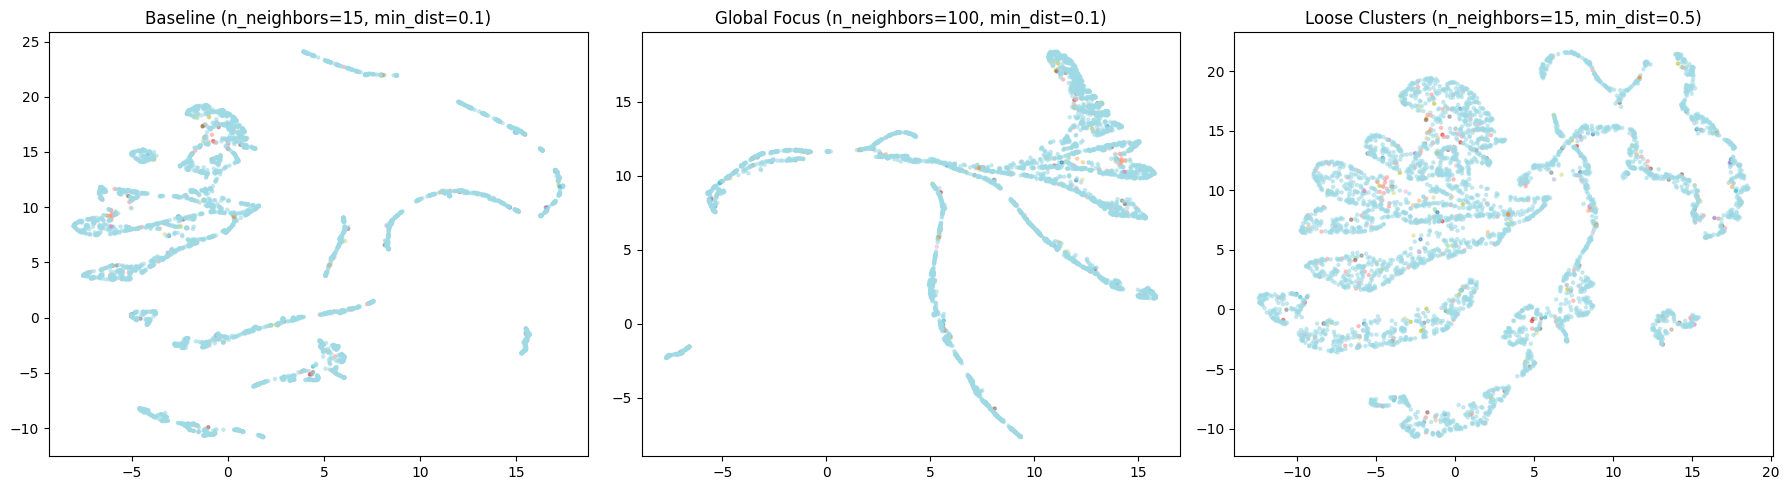

In [46]:
import matplotlib.pyplot as plt
import umap

# A quick loop to test parameter combinations side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Test 1: Standard/Baseline
print("Running Baseline UMAP...")
u1 = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(rfm_scaled_df)
axes[0].scatter(u1[:, 0], u1[:, 1], c=colors, cmap='tab20', s=5, alpha=0.5)
axes[0].set_title("Baseline (n_neighbors=15, min_dist=0.1)")

# Test 2: High Neighbors (More Global Structure)
print("Running High Neighbors UMAP...")
u2 = umap.UMAP(n_neighbors=100, min_dist=0.1, random_state=42).fit_transform(rfm_scaled_df)
axes[1].scatter(u2[:, 0], u2[:, 1], c=colors, cmap='tab20', s=5, alpha=0.5)
axes[1].set_title("Global Focus (n_neighbors=100, min_dist=0.1)")

# Test 3: High Minimum Distance ( looser clusters)
print("Running High min_dist UMAP...")
u3 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=42).fit_transform(rfm_scaled_df)
axes[2].scatter(u3[:, 0], u3[:, 1], c=colors, cmap='tab20', s=5, alpha=0.5)
axes[2].set_title("Loose Clusters (n_neighbors=15, min_dist=0.5)")

plt.tight_layout()
plt.show()

**UMAP Observations on RFM Data:**
* In case you have uncommented and run UMAP, how does UMAP's representation of the clusters compare to both PCA and t-SNE? Does it show a clearer global structure or sharper local clusters?
* Are there any "bridges" or connections between clusters that UMAP highlights better than t-SNE?
* Consider how different n_neighbors (e.g., 5, 50, 100) and min_dist (e.g., 0.0, 0.5) values might alter the UMAP embedding.

### **UMAP vs. PCA and t-SNE**

* **Compared to PCA:** UMAP is vastly superior. Instead of a single continuous linear gradient where all data points overlap, UMAP separates the noisy RFM data into a highly structured, organic geometric layout.
* **Compared to t-SNE:** UMAP strikes a much better balance between local and global data structures. While t-SNE creates scattered, independent branches, UMAP pulls the main customer base into a unified, continuous macro-structure while still maintaining highly focused local density.

### **Bridges and Connections**

* **Yes, UMAP highlights clear "bridges."** Unlike t-SNE—which aggressively tears data apart into isolated pieces—UMAP reveals continuous "trails" or structural pathways connecting different regions.
* This shows us that customer behavioral transitions (e.g., a customer moving from a high-frequency active buyer to a low-frequency at-risk buyer) happen along a continuous behavioral gradient rather than isolated, detached categories.

### **Parameter Influence**

* **`n_neighbors` (Local vs. Global Balance):**
* *Low value (e.g., 5):* Focuses on small details, fracturing the main structure into sharp, separate, stringy sub-clusters.
* *High value (e.g., 50, 100):* Focuses on the big picture, smoothing out the branches and pulling all the points into one large, interconnected global shape.


* **`min_dist` (Cluster Tightness):**
* *Low value (e.g., 0.0):* Allows points to pack together perfectly tightly, resulting in incredibly sharp, dense, and narrow structural lines.
* *High value (e.g., 0.5):* Forces points to maintain distance, causing the branches to spread out into looser, broader, and cloud-like shapes.

# 6. Comprehensive Interpretation and Business Implications (Real Data)
Now that you've visualized the real customer data using three different dimensionality reduction techniques, it's time to consolidate your observations and think about their practical business value.

**Key Questions for Interpretation:**
1. **General Cluster Shapes and Density:** Do you observe distinct, well-separated clusters, or more amorphous blobs? What does the density of points within a cluster suggest about the commonality of that customer behavior?
2. **RFM Behavior within Clusters:** While we don't have direct labels for "High-Value" or "Churn-Risk" yet, you can infer them. For example:
   * A cluster positioned far to the right on an axis related to Monetary value would likely be high-spenders.
   * A cluster with high Recency (meaning they haven't bought recently) would be candidates for re-engagement.
   * You could even go back to the original rfm_df and calculate the average R, F, M for customers within visually identified clusters (e.g., by selecting points in Plotly or by applying k-means after visualization).
3. **Geographical Influence:** How does the Country_Grouped coloring help or hinder your interpretation? Do customers from the same country tend to cluster together, suggesting regional buying habits, or are they spread across various behavioral segments?
4. **Comparison of Techniques:** Which visualization technique (PCA, t-SNE, UMAP) provided the most insightful or interpretable view for this real dataset? Why do you think that is? (Consider linearity, preservation of local/global structure).
5. **Actionable Business Strategies:** Based on the observed segments, what concrete recommendations could you make to the e-commerce company?
   * **High-Value Customers:** How would you nurture them?
   * **New/Infrequent Customers:** How would you encourage more purchases?
   * **Churn-Risk Customers:** What strategies could prevent them from leaving?
   * **Geographic-Specific Insights:** Are there opportunities for localized marketing or product offerings?



### **1. General Cluster Shapes and Density**

* **The Core:** A massive, high-density central body represents the standard retail customer base with common, predictable habits.
* **The Branches:** Elongated, low-density arms radiate outward, representing extreme behavioral trajectories (e.g., massive wholesale spend or absolute dormancy) where fewer customers fit the profile.

### **2. RFM Behavior within Clusters**

* **Active Core:** Tightly packed center points reflect frequent buyers with stable baseline revenue.
* **Wholesale Outliers:** Long, loose trails reaching far outside the main structure cleanly isolate high-value B2B/wholesale accounts.
* **Churn Trajectory:** Points drifting away toward the outer fringes map a continuous path to customer dormancy as Recency increases.

### **3. Geographical Influence**

* **UK Backbone:** Because the vast majority of the data belongs to the UK, these customers form the continuous structural spine of every single cluster.
* **Borderless Behavior:** International accounts do not form separate islands; they blend seamlessly across the behavioral arms. This proves that **purchasing metrics trump geography**—a high-volume buyer from France looks exactly like a high-volume buyer from the UK.

### **4. Comparison of Techniques**

* **PCA (Lowest Value):** Compresses highly skewed RFM variations into a single overlapping linear blob, hiding distinct behavioral groups.
* **t-SNE (Moderate Value):** Uncovers non-linear patterns well, but artificially breaks up continuous behavioral trends at optimal perplexity ($50$).
* **UMAP (Highest Value):** The most insightful method. It preserves tight local clusters while keeping global "structural bridges" intact, visibly showing the paths from active buying to churn.

### **5. Actionable Business Strategies**

* ** High-Value Accounts (The Extended Arms):** Provide dedicated account managers, bulk inventory automated pipelines, and custom wholesale pricing tiers.
* ** Core Retail Base (The Dense Body):** Deploy recommendation engines and milestone-based discount hooks (e.g., *"15% off your 3rd order"*) to drive continuous purchasing habits.
* ** Churn Risk (The Fading Trails):** Catch drifting customers early on their outward trajectory using automated win-back email sequences, exclusive "we miss you" rewards, or product feedback loops.
* ** International Strategy:** Keep marketing content consistent across regions, but lower checkout friction by introducing localized currency setups and international shipping thresholds.

This real-world exercise demonstrates that while data preprocessing and feature engineering require more effort, the insights gained can be directly translated into tangible business strategies. Visualizing your data is often the crucial first step in understanding complex patterns and driving informed decision-making.

**So I now hope you appreciate the valuable insights visualization techniques provide us with.**

Best of luck for the next Module!